From a bench in Jackson Square Park, which cafes are actually nearest? I compare straight-line distance to walking distance along the street network to see where the two disagree, and what that says about how the West Village is experienced on foot.

This notebook builds a walkable street network around the park and measures the distance from that bench to every cafe within 1200 metres, twice: once as a straight line, and once as the shortest path a person could actually walk. The gap between those two numbers is the subject. Where the street grid is regular the two measures agree. Where it is not, straight-line distance quietly overstates how close something is.


I start by importing the necessary constants

I set the study area and projection; using Jackson Square Park and the NY Long Island Plane.

Because I am using OSM, I use Overpass and Socrata to collect the data needed.

In [11]:
import os
import json
import requests

import numpy as np
import pandas as pd
import geopandas as gpd
import networkx as nx
import osmnx as ox
import matplotlib.pyplot as plt

from shapely.geometry import Point

# Constants

PROJ = 6538  # NY Long Island state plane, metres
STUDY_RADIUS = 1200  # metres, how far out to look for cafes
WALKSHED_DIST = 800  # metres, for the walkshed vs circle comparison

PARK_CENTER = (40.73903, -74.00243)  # Jackson Square Park

# Overpass and Socrata
HEADERS = {"User-Agent": "cdp-mapping-systems-coursework (mlm2399@columbia.edu)"}

os.makedirs("data", exist_ok=True)
print("working directory:", os.getcwd())

working directory: c:\Users\megan\OneDrive\Documents\CDP Mapping Systems\cdp-mapping-systems-mm\content\Assignments


**Benches from Open Street Map**
Benches are from OpenStreetMap under the tag amenity=bench.

I exported the benches for the West Village from MapComplete as .geojson and saved: C:\Users\megan\OneDrive\Documents\CDP Mapping Systems\cdp-mapping-systems-mm\content\Assignments\data\benches.geojson

NOTE: this export does not contain all NYC park benches

In [12]:
BENCH_FILE = "data/benches.geojson"

benches = gpd.read_file(BENCH_FILE)
print("raw features:", len(benches))
print("geometry types:", benches.geom_type.value_counts().to_dict())
print()
print("what is actually in here:")
print(
    benches.groupby([benches.amenity.fillna("-"), benches.leisure.fillna("-")]).size()
)

raw features: 847
geometry types: {'Point': 826, 'LineString': 21}

what is actually in here:
amenity  leisure     
-        -               120
         picnic_table     57
bench    -               670
dtype: int64


In [13]:
benches = benches[benches["amenity"] == "bench"].copy()
benches["geometry"] = benches.geometry.representative_point()
benches = benches[["id", "backrest", "material", "geometry"]].reset_index(drop=True)

benches.to_file("data/benches.geojson", driver="GeoJSON")

print(len(benches), "actual benches")
print("geometry types now:", benches.geom_type.unique().tolist())
benches.head()

670 actual benches
geometry types now: ['Point']


,id,backrest,material,geometry
0,way/261760081,no,granite,POINT (-73.99772 40.73069)
1,way/261760082,no,granite,POINT (-73.99739 40.73106)
2,way/261760083,no,granite,POINT (-73.99762 40.73103)
3,way/261760084,no,granite,POINT (-73.99728 40.73063)
4,way/261760085,no,granite,POINT (-73.99777 40.73085)


**Choosing an Origin Bench**
Not every bench in the export is within Jackson Square.

This next stage maps out the benches within the park coordinates.

In [15]:
benches = gpd.read_file("data/benches.geojson")

center = (
    gpd.GeoSeries([Point(PARK_CENTER[1], PARK_CENTER[0])], crs=4326)
    .to_crs(PROJ)
    .iloc[0]
)

bp = benches.to_crs(PROJ).copy()
bp["d_to_center"] = bp.distance(center)

park_benches = bp[bp.d_to_center < 80].sort_values("d_to_center")
print(len(park_benches), "benches within 80m of the park centre")

if len(park_benches) > 0:
    bench = park_benches.iloc[[0]].to_crs(4326)
    pt = bench.geometry.iloc[0]
    BENCH = (pt.y, pt.x)
    print("using OSM bench", bench.id.iloc[0])
else:
    # Fallback: OSM has no benches mapped inside the park.
    # Locating one by hand is a legitimate choice as long as you say so.
    BENCH = PARK_CENTER
    print("no OSM benches found in the park, using a manually placed point")

print("origin (lat, lon):", BENCH)

8 benches within 80m of the park centre
using OSM bench node/13189149158
origin (lat, lon): (40.7390169, -74.0027475)


In [16]:
# the origin as a projected shapely point, reused throughout
origin_pt = gpd.GeoSeries([Point(BENCH[1], BENCH[0])], crs=4326).to_crs(PROJ).iloc[0]

**Cafes from NYC Open Data**
These destinations come from the Department of Health and Mental Hygeine restaurant inspection results.

NOTE: this dataset has one row per inspection.
E.g. A cafe inspected 5 times will appear 5 times.
It's essential to deduplicate on camis.

In [17]:
resp = requests.get(
    "https://data.cityofnewyork.us/resource/43nn-pn8j.json",
    params={
        "$select": "camis,dba,building,street,zipcode,cuisine_description,latitude,longitude",
        "$where": "cuisine_description like '%Coffee%' and boro='Manhattan'",
        "$limit": 50000,
    },
    headers=HEADERS,
    timeout=60,
)
resp.raise_for_status()

raw = pd.DataFrame(resp.json())
raw.to_csv("data/cafes_raw.csv", index=False)

print(len(raw), "inspection rows returned")
raw.head()

10800 inspection rows returned


,camis,dba,building,street,zipcode,cuisine_description,latitude,longitude
0,50180798,MATTO ESPRESSO,530,COLUMBUS AVENUE,10024,Coffee/Tea,40.786168951906,-73.972410855946
1,50148436,THE SOIREE,796,9 AVENUE,10019,Coffee/Tea,40.765204425081,-73.987675448447
2,50057810,OCAFE,482,AVENUE OF THE AMERICAS,10011,Coffee/Tea,40.735926704359,-73.997867429083
3,50118836,CAFE LYRIA,166,CROSBY STREET,10012,Coffee/Tea,40.725850595158,-73.995309777661
4,50119587,P&T KNITWEAR CAFE,180,ORCHARD STREET,10002,Coffee/Tea,40.721845480012,-73.988304012661


**Cleaning the Cafe Data**
- some records have 0 coordinates
- some have coordinates of 0, 0
- duplicate inspections

In [18]:
cafes = raw.dropna(subset=["latitude", "longitude"]).copy()
cafes[["latitude", "longitude"]] = cafes[["latitude", "longitude"]].astype(float)
cafes = cafes[cafes.latitude != 0]
cafes = cafes.drop_duplicates(subset="camis")

cafes = gpd.GeoDataFrame(
    cafes,
    geometry=gpd.points_from_xy(cafes.longitude, cafes.latitude),
    crs=4326,
)

print(f"{len(raw)} inspection rows  ->  {len(cafes)} unique businesses")

10800 inspection rows  ->  1098 unique businesses


** Euclidean Distance and the study area

This is the straight-line distance from bench to each cafe;
does not take into account the street blocks, buildings etc.

In [19]:
study = cafes.to_crs(PROJ).copy()
study["euclidean_m"] = study.distance(origin_pt)
study = study[study.euclidean_m <= STUDY_RADIUS].copy()

print(len(study), "cafes within", STUDY_RADIUS, "m in a straight line")
study[["dba", "building", "street", "euclidean_m"]].sort_values("euclidean_m").head(10)

141 cafes within 1200 m in a straight line


,dba,building,street,euclidean_m
383,STARBUCKS COFFEE,122,GREENWICH AVENUE,20.823087
726,THINK COFFEE,73,8 AVENUE,48.509908
2445,LA PALMA CAFE,80,8 AVENUE,95.407113
210,PLANTSHED,31,JANE STREET,120.908563
3375,787 COFFEE,310,WEST 14 STREET,134.043707
375,787 COFFEE,256,WEST 15 STREET,194.559388
159,BLANK STREET,19,8 AVENUE,201.372869
990,TERREMOTO COFFEE,328,WEST 15 STREET,203.909048
589,BANTER,643,HUDSON STREET,228.585252
706,BIRCH COFFEE,56,7 AVENUE,255.428157


Note: The above just maps every cafe within the 1200 metre study area.

**Building the walk network**
This section begins to return the pedestrian-accessible ways: sidewalks, footpaths, park paths, and pedestrian streets.

In [20]:
ox.settings.log_console = True
ox.settings.use_cache = True

G = ox.graph_from_point(BENCH, dist=STUDY_RADIUS + 600, network_type="walk")

print(len(G.nodes), "nodes")
print(len(G.edges), "edges")

5540 nodes
17744 edges


**Snapping points to the network**
Cafes and benches sit in the middle of blocks and not the intersections.
Each Cafe and bench can be attached to the nearest network node.

In [21]:
s = study.to_crs(4326)

orig_node = ox.distance.nearest_nodes(G, BENCH[1], BENCH[0])
study["node"] = ox.distance.nearest_nodes(G, s.geometry.x.values, s.geometry.y.values)

print("origin node:", orig_node)
print(study["node"].nunique(), "unique nodes for", len(study), "cafes")

origin node: 8262308527
124 unique nodes for 141 cafes


**Network Distance**
This next section runs Dijkstra's algorithm once from the bench which returns the shortest distance to every reachable node.

In [22]:
lengths = nx.single_source_dijkstra_path_length(G, orig_node, weight="length")

study["network_m"] = study["node"].map(lengths)

unreachable = int(study["network_m"].isna().sum())
print(unreachable, "cafes unreachable on the network")
study = study.dropna(subset=["network_m"]).copy()

study["detour_ratio"] = study["network_m"] / study["euclidean_m"]

study[["dba", "street", "euclidean_m", "network_m", "detour_ratio"]].sort_values(
    "network_m"
).head(15).round(1)

0 cafes unreachable on the network


,dba,street,euclidean_m,network_m,detour_ratio
383,STARBUCKS COFFEE,GREENWICH AVENUE,20.8,42.9,2.1
726,THINK COFFEE,8 AVENUE,48.5,48.3,1.0
2445,LA PALMA CAFE,8 AVENUE,95.4,116.8,1.2
210,PLANTSHED,JANE STREET,120.9,144.5,1.2
375,787 COFFEE,WEST 15 STREET,194.6,174.4,0.9
3375,787 COFFEE,WEST 14 STREET,134.0,183.4,1.4
990,TERREMOTO COFFEE,WEST 15 STREET,203.9,195.9,1.0
159,BLANK STREET,8 AVENUE,201.4,232.3,1.2
589,BANTER,HUDSON STREET,228.6,247.2,1.1
1009,THE WALKERS ESPRESSO,WEST 13 STREET,363.7,270.6,0.7


In [23]:
study[["euclidean_m", "network_m", "detour_ratio"]].describe().round(2)

,euclidean_m,network_m,detour_ratio
count,141.00,141.00,141.00
mean,776.36,915.15,1.18
std,305.37,379.97,0.16
min,20.82,42.87,0.74
25%,574.79,660.27,1.07
50%,837.48,922.75,1.12
75%,1037.46,1200.91,1.28
max,1193.03,1626.10,2.06


**Maps:**
This starts exploring the Map visualisations in 4 sections

**Map 1:Context**
Where is every component involved so far?

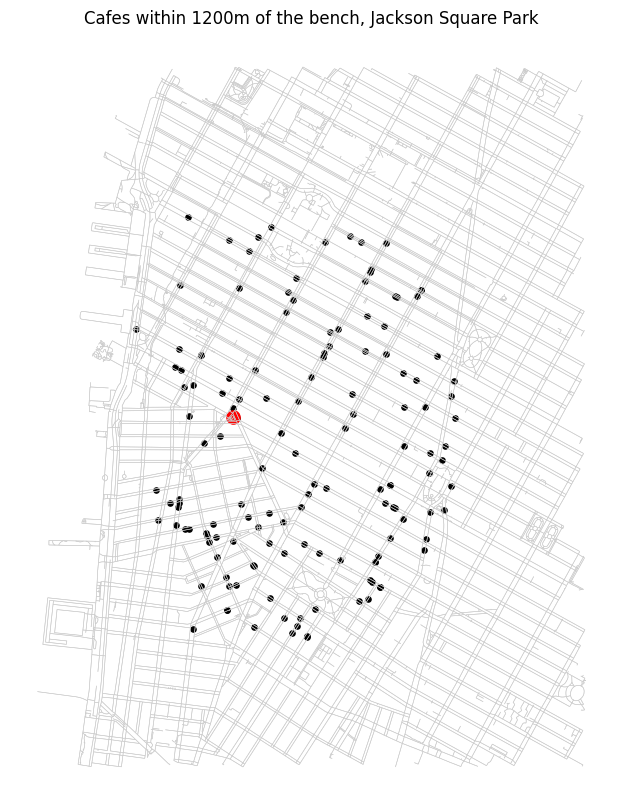

In [24]:
edges = ox.graph_to_gdfs(G, nodes=False).to_crs(PROJ)

fig, ax = plt.subplots(figsize=(10, 10))
edges.plot(ax=ax, color="#cccccc", linewidth=0.4)
study.plot(ax=ax, color="black", markersize=14)
gpd.GeoSeries([origin_pt], crs=PROJ).plot(ax=ax, color="red", markersize=90)

ax.set_axis_off()
ax.set_title(f"Cafes within {STUDY_RADIUS}m of the bench, Jackson Square Park")
plt.savefig("data/map1_context.png", dpi=200, bbox_inches="tight")
plt.show()

**Map 2: Routes to 10 x nearest cafes**

The paths a person would actually walk.

10 routes drawn


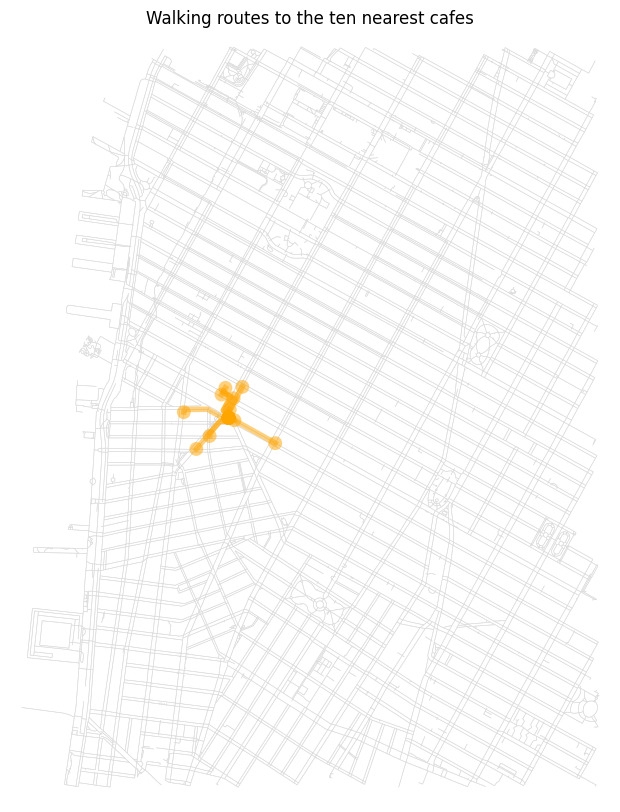

In [25]:
top = study.nsmallest(10, "network_m")

routes = []
for n in top["node"]:
    route = ox.shortest_path(G, orig_node, n, weight="length")
    if route and len(route) > 1:
        routes.append(route)

print(len(routes), "routes drawn")

fig, ax = ox.plot_graph_routes(
    G,
    routes,
    route_colors="orange",
    route_linewidth=2,
    node_size=0,
    bgcolor="white",
    edge_color="#dddddd",
    edge_linewidth=0.4,
    figsize=(10, 10),
    show=False,
    close=False,
)
ax.set_title("Walking routes to the ten nearest cafes")
plt.savefig("data/map2_routes.png", dpi=200, bbox_inches="tight")
plt.show()

**Map 3: Circle against Walkshed**
This explores everywhere you can reach within 800m walking agains a circle diagram representing 800m walked in a straight line.

the 800m walkshed covers 52.5% of the 800m circle


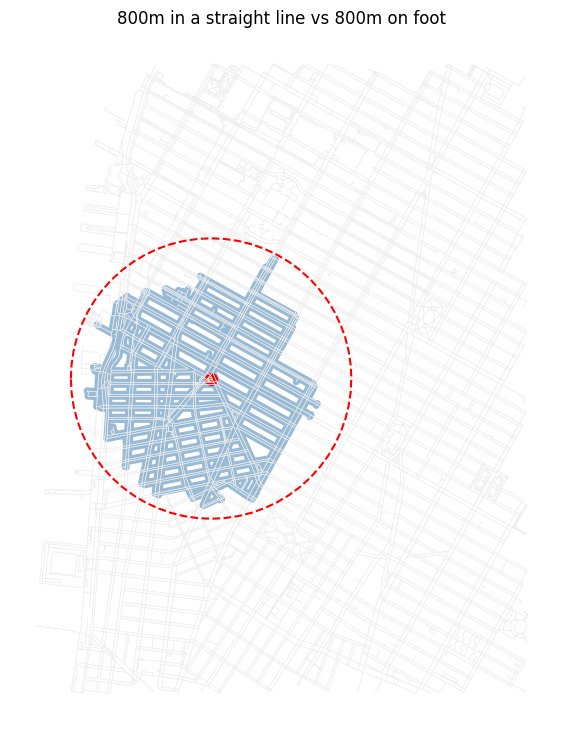

In [26]:
sub = nx.ego_graph(G, orig_node, radius=WALKSHED_DIST, distance="length")
walkshed = ox.graph_to_gdfs(sub, nodes=False).to_crs(PROJ).buffer(20).union_all()
circle = origin_pt.buffer(WALKSHED_DIST)

coverage = walkshed.area / circle.area * 100
print(
    f"the {WALKSHED_DIST}m walkshed covers {coverage:.1f}% of the {WALKSHED_DIST}m circle"
)

fig, ax = plt.subplots(figsize=(9, 9))
edges.plot(ax=ax, color="#eeeeee", linewidth=0.4)
gpd.GeoSeries([walkshed], crs=PROJ).plot(ax=ax, color="steelblue", alpha=0.55)
gpd.GeoSeries([circle], crs=PROJ).boundary.plot(
    ax=ax, color="red", linestyle="--", linewidth=1.5
)
gpd.GeoSeries([origin_pt], crs=PROJ).plot(ax=ax, color="red", markersize=70)

ax.set_axis_off()
ax.set_title(f"{WALKSHED_DIST}m in a straight line vs {WALKSHED_DIST}m on foot")
plt.savefig("data/map3_walkshed.png", dpi=200, bbox_inches="tight")
plt.show()

**Map 4: Where the two measures disagree**

This section explores which direction they lie in. Every cafe coloured by its detour ratio.

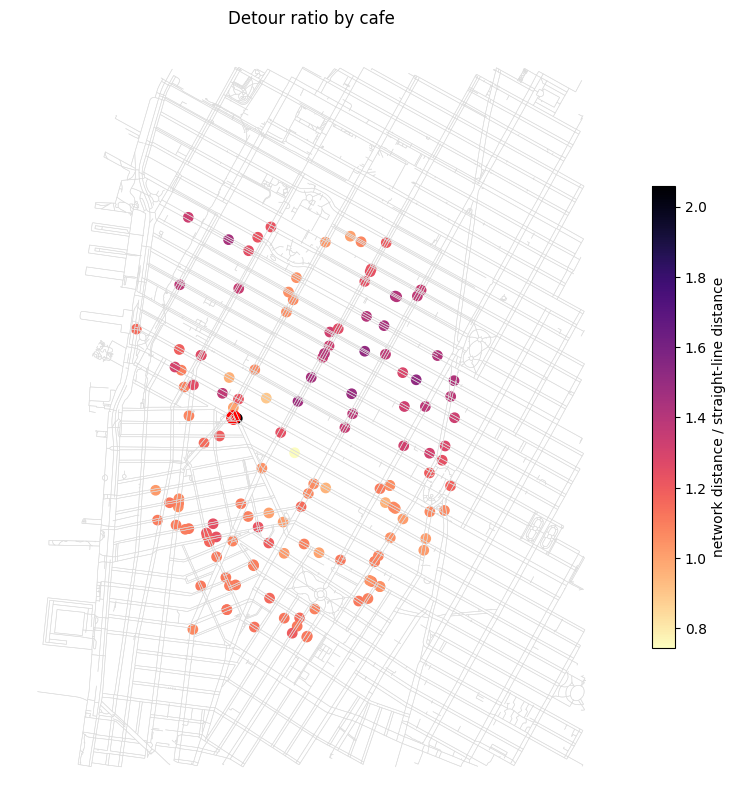

In [27]:
fig, ax = plt.subplots(figsize=(10, 10))
edges.plot(ax=ax, color="#dddddd", linewidth=0.4)
study.plot(
    ax=ax,
    column="detour_ratio",
    cmap="magma_r",
    markersize=45,
    legend=True,
    legend_kwds={"label": "network distance / straight-line distance", "shrink": 0.6},
)
gpd.GeoSeries([origin_pt], crs=PROJ).plot(ax=ax, color="red", markersize=90)

ax.set_axis_off()
ax.set_title("Detour ratio by cafe")
plt.savefig("data/map4_detour.png", dpi=200, bbox_inches="tight")
plt.show()

**Charts**

Straight line against network distance:

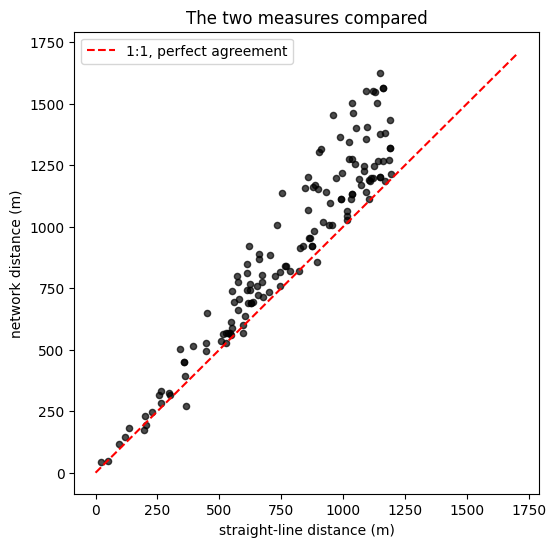

In [28]:
fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(study.euclidean_m, study.network_m, s=20, color="black", alpha=0.7)

lim = study.network_m.max() * 1.05
ax.plot([0, lim], [0, lim], color="red", linestyle="--", label="1:1, perfect agreement")

ax.set_xlabel("straight-line distance (m)")
ax.set_ylabel("network distance (m)")
ax.set_title("The two measures compared")
ax.legend()
plt.savefig("data/chart1_scatter.png", dpi=200, bbox_inches="tight")
plt.show()

Charts: Distribution of detour ratios

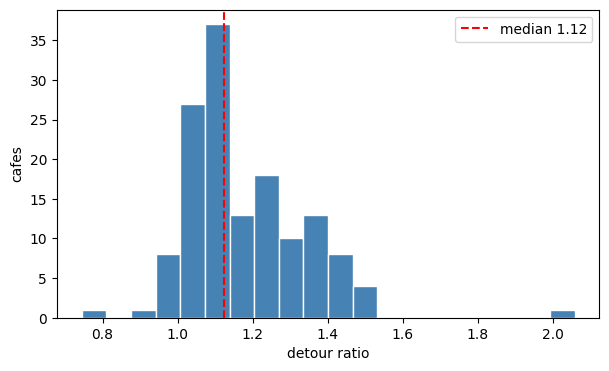

In [29]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.hist(study.detour_ratio, bins=20, color="steelblue", edgecolor="white")
ax.axvline(
    study.detour_ratio.median(),
    color="red",
    linestyle="--",
    label=f"median {study.detour_ratio.median():.2f}",
)

ax.set_xlabel("detour ratio")
ax.set_ylabel("cafes")
ax.legend()
plt.savefig("data/chart2_hist.png", dpi=200, bbox_inches="tight")
plt.show()

How does this ranking change?
Direct metric path vs actual walking metric path

In [30]:
e_rank = study.nsmallest(10, "euclidean_m")[["camis", "dba"]].reset_index(drop=True)
n_rank = study.nsmallest(10, "network_m")[["camis", "dba"]].reset_index(drop=True)

comparison = pd.DataFrame(
    {
        "nearest by straight line": e_rank.dba,
        "nearest by walking": n_rank.dba,
    }
)
comparison.index = comparison.index + 1

dropped = set(e_rank.camis) - set(n_rank.camis)
print(len(dropped), "of the straight-line top 10 fall out of the walking top 10")
comparison

1 of the straight-line top 10 fall out of the walking top 10


,nearest by straight line,nearest by walking
1,STARBUCKS COFFEE,STARBUCKS COFFEE
2,THINK COFFEE,THINK COFFEE
3,LA PALMA CAFE,LA PALMA CAFE
4,PLANTSHED,PLANTSHED
5,787 COFFEE,787 COFFEE
6,787 COFFEE,787 COFFEE
7,BLANK STREET,TERREMOTO COFFEE
8,TERREMOTO COFFEE,BLANK STREET
9,BANTER,BANTER
10,BIRCH COFFEE,THE WALKERS ESPRESSO


In [31]:
# the cafes whose ranking changes most
study["rank_euclidean"] = study.euclidean_m.rank().astype(int)
study["rank_network"] = study.network_m.rank().astype(int)
study["rank_change"] = study.rank_euclidean - study.rank_network

study.reindex(study.rank_change.abs().sort_values(ascending=False).index)[
    ["dba", "street", "rank_euclidean", "rank_network", "rank_change", "detour_ratio"]
].head(10).round(2)

,dba,street,rank_euclidean,rank_network,rank_change,detour_ratio
429,:3 COFFEE,WEST 21 STREET,91,132,-41,1.52
1026,HEINEKEN 0.0 ULTIMATE,WEST 23 STREET,84,120,-36,1.44
1081,CAFE FRED,BROADWAY,135,99,36,1.01
3654,CAFE AMBROSIA,WEST 23 STREET,85,121,-36,1.45
271,SIP COFFEE,WEST 27 STREET,119,85,34,1.01
1225,VIVI BUBBLE TEA,WEST 23 STREET,73,106,-33,1.40
597,MASTERCARD,5 AVENUE,93,126,-33,1.38
575,OUTRO,BROADWAY,141,109,32,1.02
6440,VELVETTE ESPRESSO BAR,WEST 25 STREET,103,134,-31,1.45
314,JOE COFFEE,WEST 21 STREET,65,91,-26,1.51


**Distances among the cafe network**

This measures the cafes against each other and not the Jackson Square Park bench.



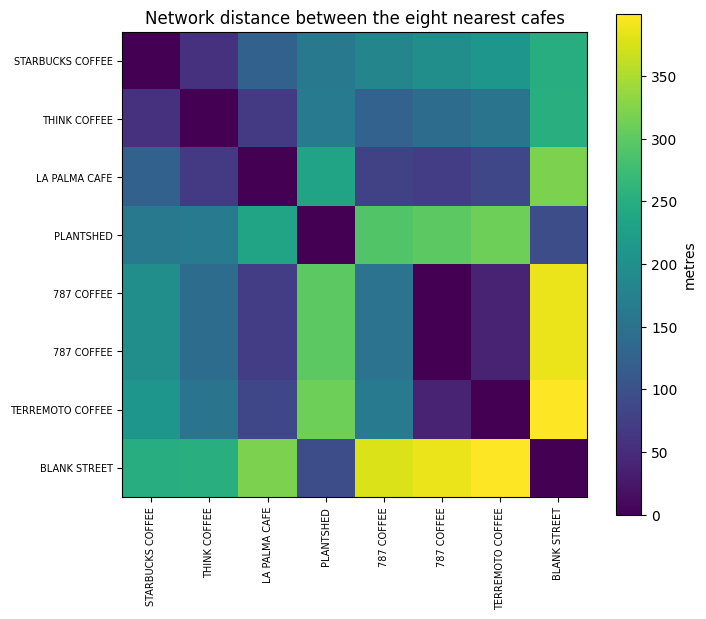

,STARBUCKS COFFEE,THINK COFFEE,LA PALMA CAFE,PLANTSHED,787 COFFEE,787 COFFEE,TERREMOTO COFFEE,BLANK STREET
STARBUCKS COFFEE,0.0,56.0,125.0,161.0,182.0,197.0,210.0,249.0
THINK COFFEE,56.0,0.0,69.0,164.0,126.0,141.0,154.0,252.0
LA PALMA CAFE,125.0,69.0,0.0,233.0,79.0,73.0,85.0,321.0
PLANTSHED,161.0,164.0,233.0,0.0,290.0,299.0,312.0,94.0
787 COFFEE,197.0,141.0,73.0,299.0,152.0,0.0,38.0,387.0
787 COFFEE,197.0,141.0,73.0,299.0,152.0,0.0,38.0,387.0
TERREMOTO COFFEE,210.0,154.0,85.0,312.0,164.0,38.0,0.0,400.0
BLANK STREET,249.0,252.0,321.0,94.0,378.0,387.0,400.0,0.0


In [32]:
sel = study.nsmallest(8, "network_m")
node_ids = sel["node"].tolist()
names = sel["dba"].tolist()

matrix = pd.DataFrame(index=names, columns=names, dtype=float)
for name, node in zip(names, node_ids):
    L = nx.single_source_dijkstra_path_length(G, node, weight="length")
    matrix.loc[name] = [L.get(j, np.nan) for j in node_ids]

fig, ax = plt.subplots(figsize=(7.5, 6.5))
im = ax.imshow(matrix.values.astype(float), cmap="viridis")
ax.set_xticks(range(len(names)))
ax.set_xticklabels(names, rotation=90, fontsize=7)
ax.set_yticks(range(len(names)))
ax.set_yticklabels(names, fontsize=7)
ax.set_title("Network distance between the eight nearest cafes")
fig.colorbar(im, ax=ax, label="metres")
plt.savefig("data/chart3_matrix.png", dpi=200, bbox_inches="tight")
plt.show()

matrix.round(0)

**Export**

Saving the results of the cafe bench study

In [33]:
out = study[
    [
        "camis",
        "dba",
        "building",
        "street",
        "zipcode",
        "euclidean_m",
        "network_m",
        "detour_ratio",
        "geometry",
    ]
].copy()

out.to_crs(4326).to_file("data/cafes_distance.geojson", driver="GeoJSON")
out.drop(columns="geometry").to_csv("data/cafes_distance.csv", index=False)

print("saved", len(out), "cafes")
print(sorted(os.listdir("data")))

saved 141 cafes
['benches.geojson', 'cafes_distance.csv', 'cafes_distance.geojson', 'cafes_raw.csv', 'chart1_scatter.png', 'chart2_hist.png', 'chart3_matrix.png', 'map1_context.png', 'map2_routes.png', 'map3_walkshed.png', 'map4_detour.png']


**MY REFLECTION**

For this assignment, I first explored the data provided by OpenStreetMap to find a bench in Jackson Square Park. 
I filtered the benches to find one that was within 80 meters of the park center and used its coordinates as the 
origin point for my analysis.

Through a series of mapping and visualisation steps, I was able to identify cafes within a 1200-meter radius of the 
bench, calculate both straight-line and network distances, and analyze the detour ratios.

The most notable diagram to me was the 800m circle against walkshed map. It was interesting to see how much of 
the area within a straight-line distance of 800m was actually reachable by walking, and it highlighted the importance 
of considering the actual street network when analyzing accessibility.

The network study does not consider factors such as traffic, pedestrian crossings, or other obstacles that may affect 
walking times. For example in my local dataset, I have a whole section of a street blocked off for construction, which 
would make the actual walking distance longer than what is calculated in this study.